In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,accuracy_score,r2_score
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
data = {
"area_sqft": [800,850,900,950,1000,1050,1100,1150,1200,1250,
              1300,1350,1400,1450,1500,1550,1600,1650,1700,1750,
              1800,1850,1900,1950,2000,2050,2100,2150,2200,2250,
              2300,2350,2400,2450,2500,2550,2600,2650,2700,2750,
              2800,2850,2900,2950,3000,3050,3100,3150,3200,3250],

"bedrooms": [2,2,2,2,3,3,3,3,3,3,
             3,3,3,4,4,4,4,4,4,4,
             4,4,4,4,4,4,5,5,5,5,
             5,5,5,5,5,5,5,5,5,5,
             5,5,5,5,5,5,5,5,5,5],

"bathrooms": [1,1,1,2,2,2,2,2,2,2,
              2,2,3,3,3,3,3,3,3,3,
              3,3,3,3,3,3,3,4,4,4,
              4,4,4,4,4,4,4,4,4,4,
              4,4,4,4,4,4,4,4,4,4],

"floors": [1,1,1,1,1,1,1,2,2,2,
           2,2,2,2,2,2,2,2,2,2,
           2,2,2,2,2,2,2,3,3,3,
           3,3,3,3,3,3,3,3,3,3,
           3,3,3,3,3,3,3,3,3,3],

"age_years": [10,9,8,7,6,5,4,5,6,7,
              4,3,2,5,6,4,3,2,1,2,
              3,4,2,1,0,1,2,3,4,2,
              1,0,1,2,3,2,1,0,1,2,
              1,0,1,2,1,0,1,2,1,0],

"distance_city_km": [15,14,13,12,11,10,9,8,7,6,
                     5,6,7,8,7,6,5,4,3,4,
                     5,6,4,3,2,3,4,5,6,4,
                     3,2,3,4,5,4,3,2,3,4,
                     3,2,3,4,3,2,3,4,3,2],

"price_lakh": [30,32,34,38,45,48,50,55,58,60,
               62,65,70,75,78,80,85,88,90,92,
               95,98,100,105,110,115,120,125,130,135,
               138,140,145,148,150,155,158,160,165,168,
               170,175,178,180,185,188,190,195,198,200]
}

In [3]:
df=pd.DataFrame(data)

In [4]:
df

,area_sqft,bedrooms,bathrooms,floors,age_years,distance_city_km,price_lakh
0,800,2,1,1,10,15,30
1,850,2,1,1,9,14,32
2,900,2,1,1,8,13,34
3,950,2,2,1,7,12,38
4,1000,3,2,1,6,11,45
5,1050,3,2,1,5,10,48
6,1100,3,2,1,4,9,50
7,1150,3,2,2,5,8,55
8,1200,3,2,2,6,7,58
9,1250,3,2,2,7,6,60


In [5]:
X=df.drop("price_lakh",axis=1)
y=df["price_lakh"]

In [6]:
X=pd.get_dummies(X)

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [8]:
scaler=StandardScaler()

In [9]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
knnmodel=KNeighborsRegressor()

In [11]:
grid = {
    "n_neighbors": [5]
}

In [12]:
knncv=GridSearchCV(knnmodel,param_grid=grid,scoring="neg_mean_squared_error",cv=5)
knncv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'n_neighbors': [5]}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate par

In [13]:
knnpre=knncv.predict(X_test)

In [14]:
knnpre

array([ 87.2, 163.6, 149.2, 185.6,  95. , 189.6,  95. , 100. , 149.2,
        95. ,  77.4,  43.8, 161.6,  64. ,  38.8])

In [15]:
r2=r2_score(y_test,knnpre)

In [16]:
r2

0.9628257755542727

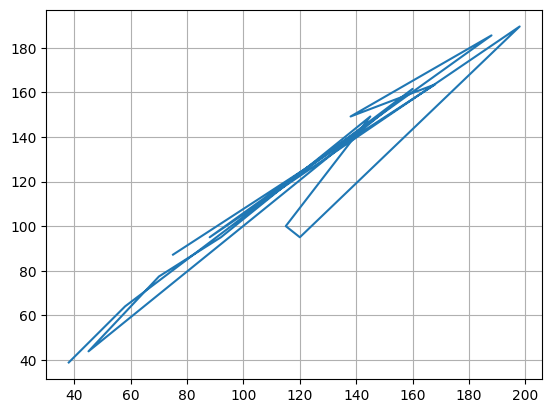

In [21]:
plt.plot(y_test,knnpre)
plt.grid()